# Model Selection — Information Criteria (pmr_paper)

Uses `data/features.csv` (17 monthly factors from `scripts/data_preparation.py`).
Features are standardized with `StandardScaler` before fitting.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler


def _find_pmr_root() -> Path:
    """Locate pmr_paper/ from the notebook working directory."""
    start = Path.cwd().resolve()
    for parent in [start, *start.parents]:
        if (parent / "scripts" / "paths.py").is_file():
            return parent
    raise FileNotFoundError(
        "Could not locate pmr_paper (scripts/paths.py not found). "
        "Run this notebook from inside the pmr_paper tree."
    )


PROJECT_ROOT = _find_pmr_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.paths import FEATURES_PATH, load_features

features = load_features()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features.values)

print(f"Project root: {PROJECT_ROOT}")
print(f"Features: {FEATURES_PATH}")
print(f"Shape after cleaning: {features.shape}")


from scripts.criteria import run_information_criteria


Project root: /Users/antoinea/Desktop/Master_Thesis
Features: /Users/antoinea/Desktop/Master_Thesis/data/features.csv
Shape after cleaning: (663, 17)


## Model Selection - GMM

Gaussian Mixture benchmark on scaled features.

Running optimization for Gaussian Mixture Model with K=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]...


,AIC,BIC,ICL
K,,,
1,23719.716013,24484.167761,24484.167761
2,21563.463608,23096.863880,23168.572694
3,17242.860102,19545.208897,19581.812612
4,16543.219279,19614.516597,19651.466092
5,15849.249471,19689.495313,19742.067573
6,15829.920315,20439.114680,20477.710660
7,15576.619788,20954.762676,20998.380663
8,15370.882620,21517.974032,21567.409266
9,15208.350190,22124.390125,22159.948566


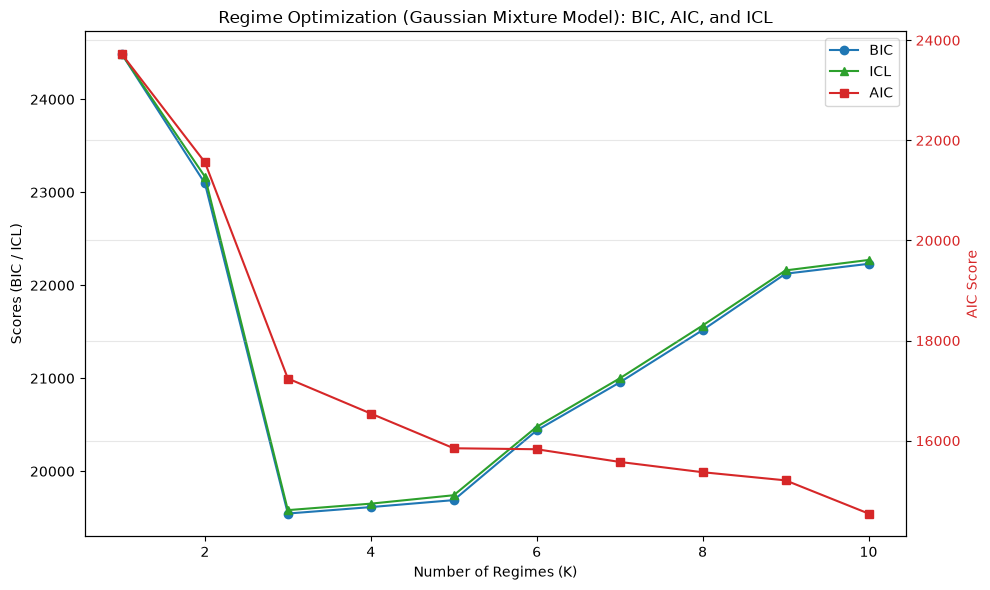

Optimal K (AIC): 10
Optimal K (BIC): 3
Optimal K (ICL): 3


In [2]:
from sklearn.mixture import GaussianMixture

def fit_gmm(k):
    """Builds and fits a GMM for a given K."""
    gmm = GaussianMixture(n_components=k, covariance_type="full", n_init=20, random_state=42)
    gmm.fit(X_scaled)
    return gmm

# Run the analysis
gmm_results = run_information_criteria(
    model_factory=fit_gmm, 
    X=X_scaled, 
    k_range=range(1, 11), 
    model_name="Gaussian Mixture Model"
)